# Load an Excel file and access a specific sheet

In [14]:
# !pip install umap-learn
# !pip install numpy pandas scipy mne
# !pip install mne-connectivity
# !pip install openpyxl
#!pip install shap
# Load an Excel file and access a specific sheet
import os, pandas as pd
output_dir = "/rsrch7/home/ip_rsrch/wulab/Mori/EEG/data_txt/all_features/"

# Example: Load a specific Excel file
excel_file = os.path.join(output_dir, "CIPN3001_NFB.xlsx")  # Change to your desired file

# Method 1: List all available sheets
xl_file = pd.ExcelFile(excel_file)
print("Available sheets:")
for sheet_name in xl_file.sheet_names:
    print(f"  - {sheet_name}")

print("\n" + "="*50 + "\n")

# Method 2: Load a specific sheet by name
sheet_name = "FFT_abs_bandpower_uV2"  # Change to your desired sheet name
df = pd.read_excel(excel_file, sheet_name=sheet_name)
print(f"Loaded sheet: {sheet_name}")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

# Method 3: Load multiple sheets at once
sheets_to_load = ["FFT_abs_bandpower_uV2", "FFT_rel_bandpower_pct", "PeakFreq_Hz"]
data_dict = {}
for sheet in sheets_to_load:
    data_dict[sheet] = pd.read_excel(excel_file, sheet_name=sheet)

print(f"\nLoaded {len(data_dict)} sheets into dictionary")
print(f"Keys: {list(data_dict.keys())}")

# Method 4: Load all sheets at once
all_sheets = pd.read_excel(excel_file, sheet_name=None)  # Returns a dictionary of all sheets
print(f"\nTotal sheets loaded: {len(all_sheets)}")

# Show dimensions (features) for each sheet
print("\n" + "="*50)
print("Sheet Dimensions (Features per sheet):")
print("="*50)
for sheet_name, df_sheet in all_sheets.items():
    if sheet_name == 'meta':
        # Meta sheet is special - just show its shape
        print(f"{sheet_name:30s} | Shape: {str(df_sheet.shape):15s} | Total values: {df_sheet.size}")
    else:
        # For feature sheets: rows = channels, columns = features
        # Total features when flattened = rows * columns
        n_channels = df_sheet.shape[0]
        n_features_per_channel = df_sheet.shape[1]
        total_features = df_sheet.size  # rows * columns (flattened)
        print(f"{sheet_name:30s} | Shape: {str(df_sheet.shape):15s} | Channels: {n_channels:3d} | Features/channel: {n_features_per_channel:3d} | Total features (flattened): {total_features:5d}")

Available sheets:
  - meta
  - FFT_abs_bandpower_uV2
  - Z_FFT_abs_bandpower_uV2
  - FFT_rel_bandpower_pct
  - Z_FFT_rel_bandpower_pct
  - FFT_abs_1to50Hz_uV2
  - Z_FFT_abs_1to30Hz_uV2
  - Z_FFT_abs_1to50Hz_uV2
  - FFT_rel_1to50Hz_pct
  - Z_FFT_rel_1to30Hz_pct
  - Z_FFT_rel_1to50Hz_pct
  - PeakFreq_Hz
  - Z_PeakFreq_Hz
  - FFT_Coherence
  - Z_FFT_Coherence
  - FFT_PhaseLag_PLI
  - Z_FFT_PhaseLag_PLI


Loaded sheet: FFT_abs_bandpower_uV2
Shape: (19, 15)

First few rows:
  Channel         Delta        Theta       Alpha        Beta   HighBeta  \
0  FP1-LE     38.238512     4.128686    2.315065   28.494356  10.593170   
1  FP2-LE     23.345379     2.804118    2.133777   28.062195   9.817158   
2   F7-LE     19.260395     6.789990   10.565571   32.674180  15.812257   
3   F3-LE  11654.670171  1369.431272  352.111938  301.789499  30.561157   
4   Fz-LE      6.178930     0.761850    0.603269    2.371195   0.748935   

       Gamma  HighGamma      Alpha1      Alpha2       Beta1      Beta2  \
0

# Load Output

In [6]:
df = pd.read_excel("/rsrch7/home/ip_rsrch/wulab/Mori/EEG/Randomization factors and Primary outcome.xlsx")
print(df.columns)
df.head(1)

Index(['Unnamed: 0', 'Patient number', 'Event Name', 'CORe acct #',
       'Group assignment - can code the variables (NFB=1; NFB+DL=2; DL=3)',
       'Pain Unpleasantness', 'Age', 'Date of Birth', 'Sex:', 'Cancer Stage',
       'Marital Status',
       'With what racial category do you most strongly identify?',
       'Ethnicity ', 'How many months have you been experiencing neuropathy?',
       'Have you had neuropathy for:'],
      dtype='object')


,Unnamed: 0,Patient number,Event Name,CORe acct #,Group assignment - can code the variables (NFB=1; NFB+DL=2; DL=3),Pain Unpleasantness,Age,Date of Birth,Sex:,Cancer Stage,Marital Status,With what racial category do you most strongly identify?,Ethnicity,How many months have you been experiencing neuropathy?,Have you had neuropathy for:
0,Baseline is line one for each person or T1,1,T1,3001.0,NFB,7.0,76.0,1947-12-09,Female,NaN,Single,White/ Caucasian,Not Hispanic or Latino,132,6 years or more


# Histograms

Patients: 181
Mean change: -2.52
Improved: 151, Worsened: 14
count    181.000000
mean      -2.519337
std        2.356059
min      -10.000000
25%       -4.000000
50%       -2.000000
75%       -1.000000
max        4.000000
Name: Diff, dtype: float64


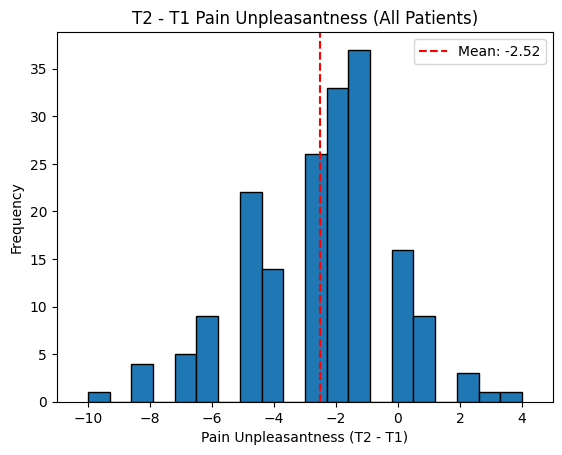

In [7]:
# T2 - T1 difference in Pain Unpleasantness
import matplotlib.pyplot as plt

# Pivot and calculate difference
diff = df[df['Event Name'].isin(['T1', 'T2'])].pivot_table(
    index='Patient number', columns='Event Name', values='Pain Unpleasantness'
).dropna()
diff['Diff'] = diff['T2'] - diff['T1']

# Summary
print(f"Patients: {len(diff)}")
print(f"Mean change: {diff['Diff'].mean():.2f}")
print(f"Improved: {(diff['Diff'] < 0).sum()}, Worsened: {(diff['Diff'] > 0).sum()}")
print(diff['Diff'].describe())

# Plot
plt.hist(diff['Diff'], bins=20, edgecolor='black')
plt.axvline(diff['Diff'].mean(), color='r', linestyle='--', label=f"Mean: {diff['Diff'].mean():.2f}")
plt.xlabel('Pain Unpleasantness (T2 - T1)')
plt.ylabel('Frequency')
plt.xlim(-11, 5)
plt.title('T2 - T1 Pain Unpleasantness (All Patients)')
plt.legend()
plt.show()

#diff[['T1', 'T2', 'Diff']].sort_values('Diff')


Found 78 patients with XLSX in all_features: [1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 17, 26, 31, 32, 35, 37, 39, 41, 42, 44, 48, 49, 54, 59, 60, 62, 66, 67, 72, 77, 78, 83, 84, 87, 90, 101, 102, 103, 106, 109, 111, 123, 124, 125, 127, 128, 129, 141, 142, 146, 152, 155, 156, 158, 159, 162, 166, 172, 175, 177, 180, 191, 192, 195, 198, 200, 201, 205, 211, 216, 222, 224, 225, 233, 253, 328, 330]
Patients in diff with XLSX: 75


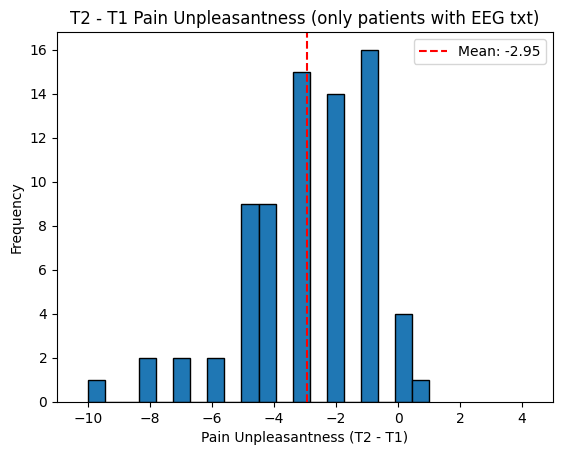

In [10]:
# Restrict to patients who have XLSX in all_features and plot histogram
import glob, re

output_dir = "/rsrch7/home/ip_rsrch/wulab/Mori/EEG/data_txt/all_features/"

# Collect patient numbers from filenames like CIPN3002_NFB_DUL.xlsx
xlsx_files = glob.glob(os.path.join(output_dir, "CIPN3*.xlsx"))
patient_ids = set()
for f in xlsx_files:
    m = re.search(r"CIPN3(\d{3})", os.path.basename(f))
    if m:
        patient_ids.add(int(m.group(1)))

print(f"Found {len(patient_ids)} patients with XLSX in all_features: {sorted(patient_ids)}")

# diff is indexed by 'Patient number' from the earlier cell
diff_with_xlsx = diff[diff.index.isin(patient_ids)].copy()
print(f"Patients in diff with XLSX: {len(diff_with_xlsx)}")

plt.hist(diff_with_xlsx['Diff'], bins=20, edgecolor='black')
# plt.axvline(diff_with_xlsx['Diff'].mean(), color='r', linestyle='--',
#             label=f"Mean: {diff_with_xlsx['Diff'].mean():.2f}")
plt.axvline(diff_with_xlsx['Diff'].mean(), color='r', linestyle='--', label=f"Mean: {diff_with_xlsx['Diff'].mean():.2f}")
plt.xlabel('Pain Unpleasantness (T2 - T1)')
plt.ylabel('Frequency')
plt.xlim(-11, 5)
plt.title('T2 - T1 Pain Unpleasantness (only patients with EEG txt)')
plt.legend()
plt.show()

#diff_with_xlsx[['T1', 'T2', 'Diff']].sort_values('Diff')


Median Pain Unpleasantness (T2-T1): -3.00
Patients below median: 25
Patients above median: 50

Processing FFT_abs_bandpower_uV2...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


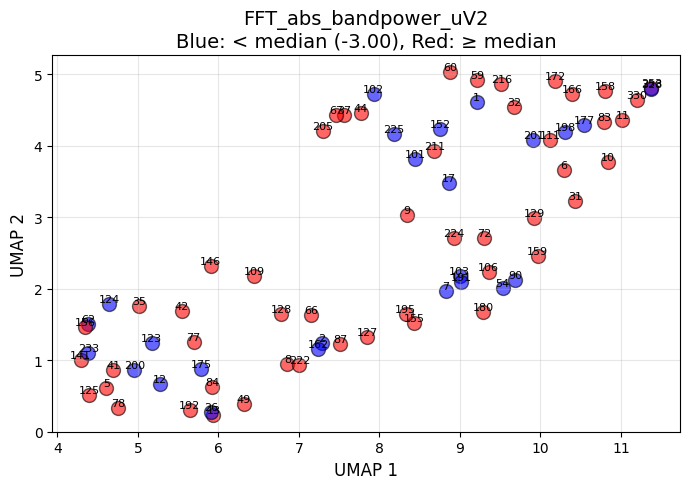

  Processed 75 patients

Processing Z_FFT_abs_bandpower_uV2...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


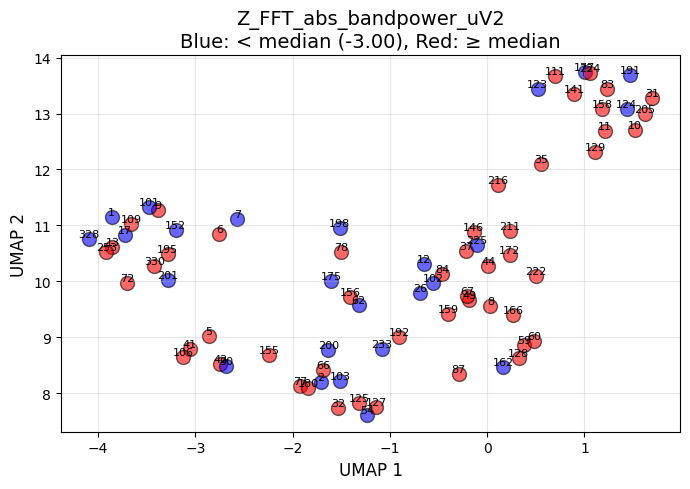

  Processed 75 patients

Processing FFT_rel_bandpower_pct...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


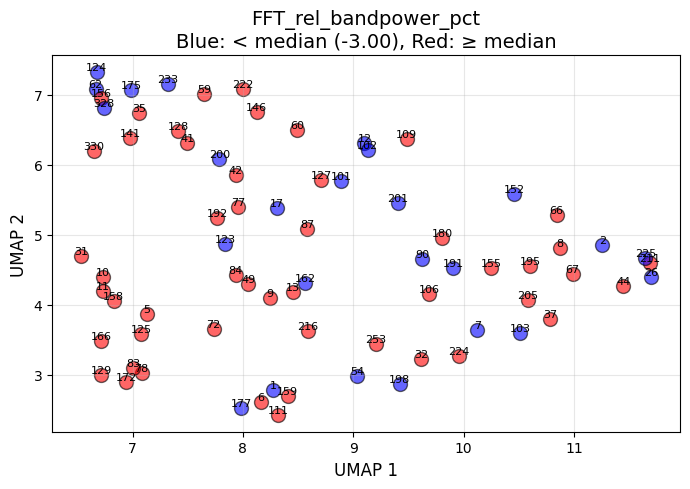

  Processed 75 patients

Processing Z_FFT_rel_bandpower_pct...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


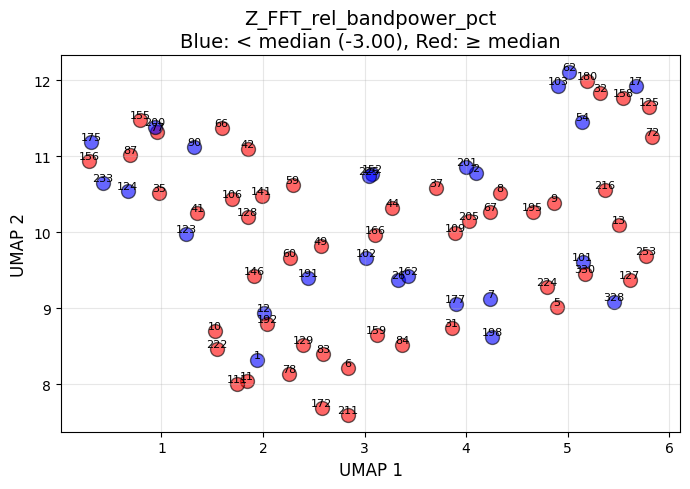

  Processed 75 patients

Processing FFT_abs_1to50Hz_uV2...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


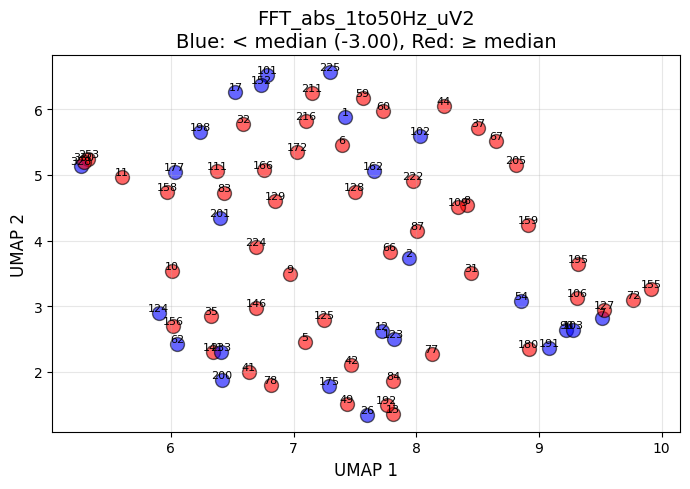

  Processed 75 patients

Processing Z_FFT_abs_1to30Hz_uV2...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


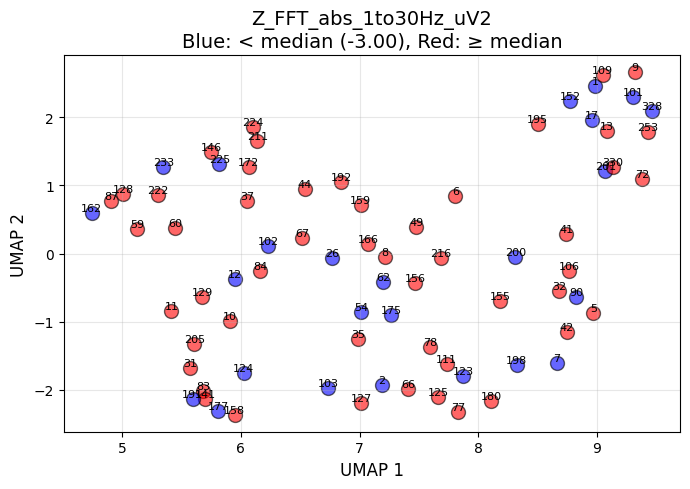

  Processed 75 patients

Processing Z_FFT_abs_1to50Hz_uV2...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


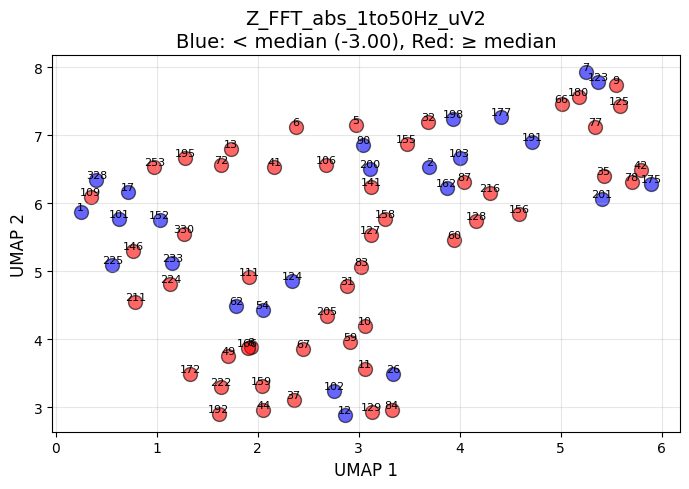

  Processed 75 patients

Processing FFT_rel_1to50Hz_pct...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


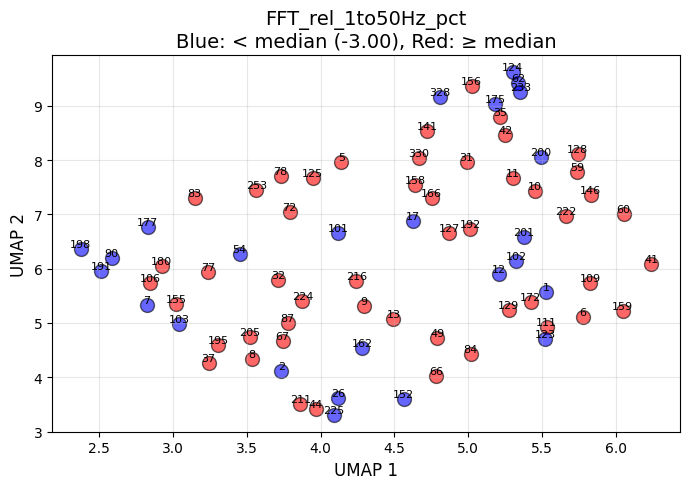

  Processed 75 patients

Processing Z_FFT_rel_1to30Hz_pct...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


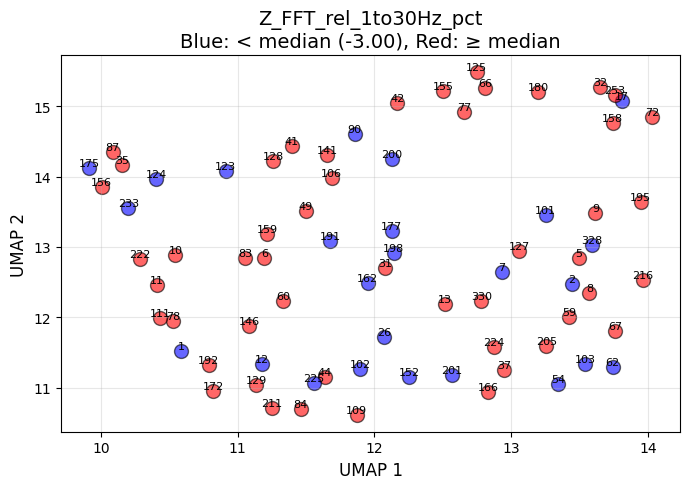

  Processed 75 patients

Processing Z_FFT_rel_1to50Hz_pct...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


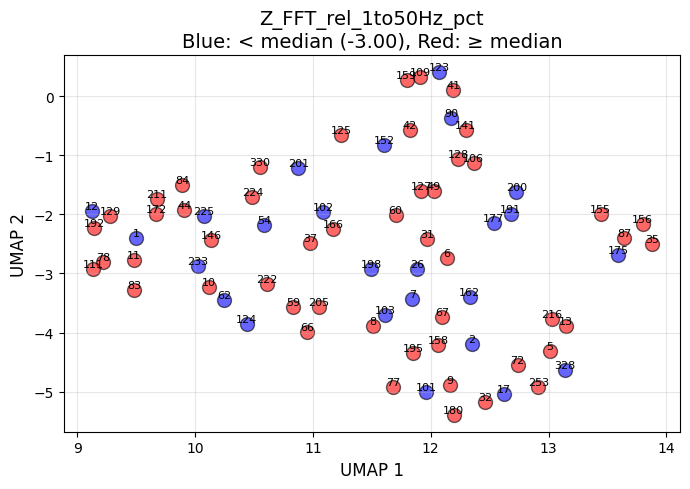

  Processed 75 patients

Processing PeakFreq_Hz...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


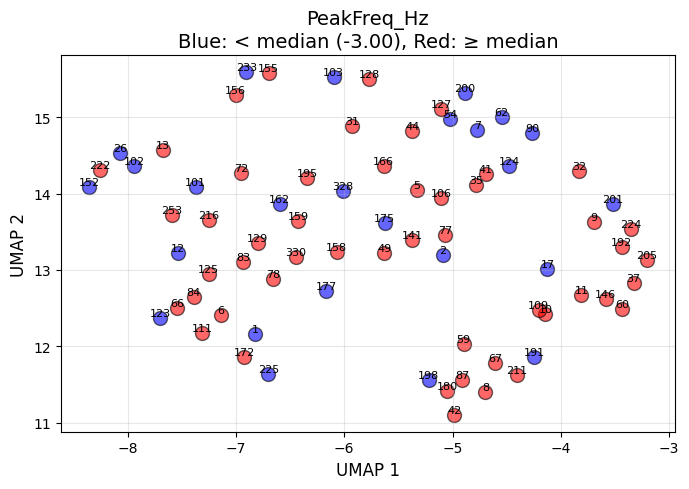

  Processed 75 patients

Processing Z_PeakFreq_Hz...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


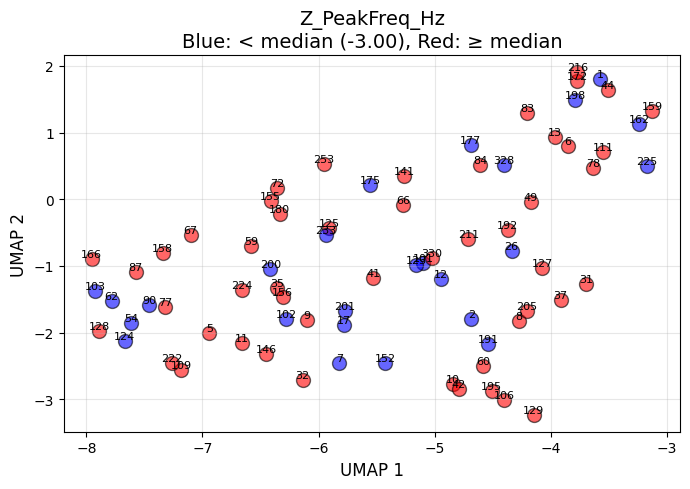

  Processed 75 patients

Processing FFT_Coherence...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


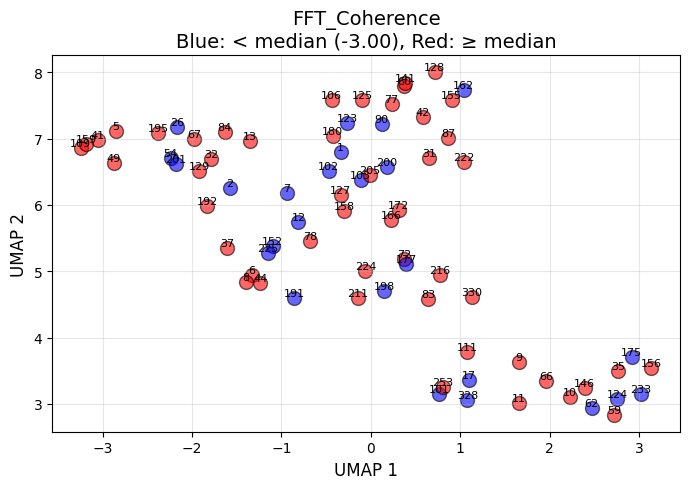

  Processed 75 patients

Processing Z_FFT_Coherence...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


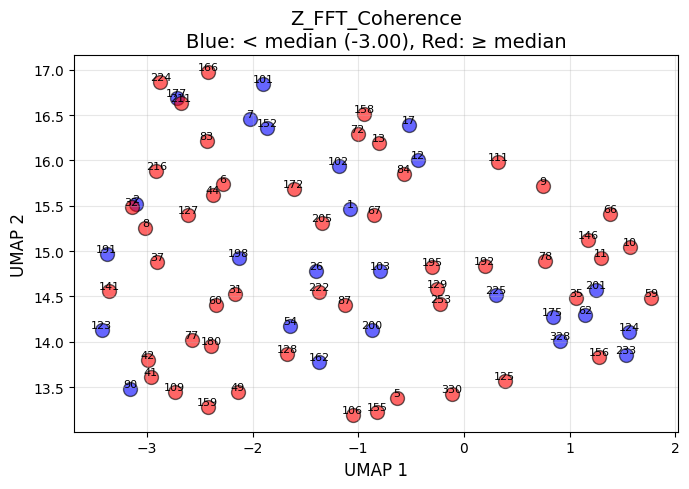

  Processed 75 patients

Processing FFT_PhaseLag_PLI...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


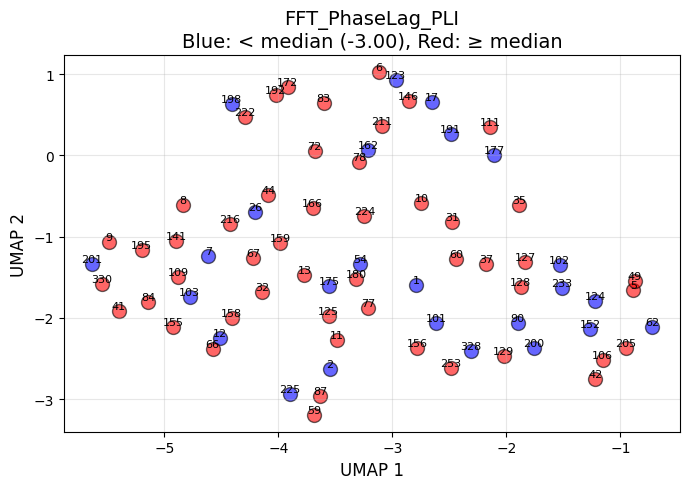

  Processed 75 patients

Processing Z_FFT_PhaseLag_PLI...


/opt/venv/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


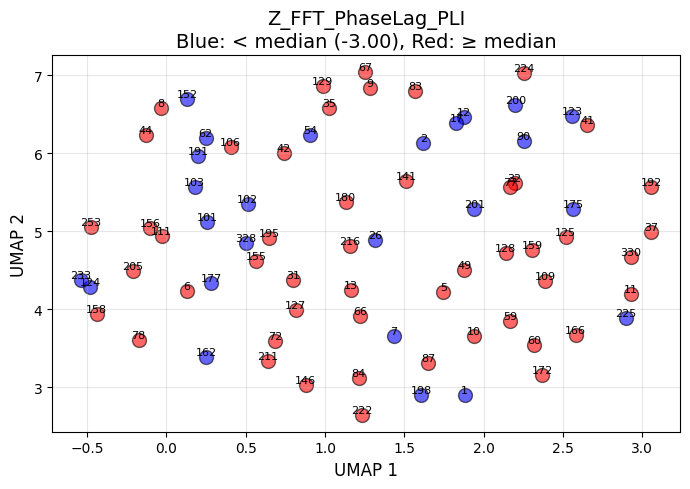

  Processed 75 patients



In [13]:
# UMAP for each feature sheet, colored by Pain Unpleasantness (T2-T1) median split
import umap
from sklearn.preprocessing import StandardScaler
import numpy as np

output_dir = "/rsrch7/home/ip_rsrch/wulab/Mori/EEG/data_txt/all_features/"

# Get patient IDs with XLSX files
xlsx_files = glob.glob(os.path.join(output_dir, "CIPN3*.xlsx"))
patient_ids = {} #{1: '/rsrch7/home/ip_rsrch/wulab/Mori/EEG/data_txt/all_features/CIPN3001_NFB.xlsx',...}
for f in xlsx_files:
    m = re.search(r"CIPN3(\d{3})", os.path.basename(f))
    if m:
        patient_ids[int(m.group(1))] = f

# Get Pain Unpleasantness differences for these patients
diff_with_xlsx = diff[diff.index.isin(patient_ids.keys())].copy()
median_diff = diff_with_xlsx['Diff'].median()
print(f"Median Pain Unpleasantness (T2-T1): {median_diff:.2f}")
print(f"Patients below median: {(diff_with_xlsx['Diff'] < median_diff).sum()}")
print(f"Patients above median: {(diff_with_xlsx['Diff'] >= median_diff).sum()}\n")

# Define all sheets to process
sheets = [
    "FFT_abs_bandpower_uV2",
    "Z_FFT_abs_bandpower_uV2",
    "FFT_rel_bandpower_pct",
    "Z_FFT_rel_bandpower_pct",
    "FFT_abs_1to50Hz_uV2",
    "Z_FFT_abs_1to30Hz_uV2",
    "Z_FFT_abs_1to50Hz_uV2",
    "FFT_rel_1to50Hz_pct",
    "Z_FFT_rel_1to30Hz_pct",
    "Z_FFT_rel_1to50Hz_pct",
    "PeakFreq_Hz",
    "Z_PeakFreq_Hz",
    "FFT_Coherence",
    "Z_FFT_Coherence",
    "FFT_PhaseLag_PLI",
    "Z_FFT_PhaseLag_PLI"
]

# Process each sheet
for sheet_name in sheets:
    print(f"Processing {sheet_name}...")
    
    # Collect data for all patients
    all_data = []
    patient_nums = []
    colors = []
    
    for patient_num, xlsx_path in patient_ids.items():
        if patient_num not in diff_with_xlsx.index:
            continue
            
        try:
            df_sheet = pd.read_excel(xlsx_path, sheet_name=sheet_name, index_col=0)
            # Flatten the dataframe (channels x features -> 1D vector)
            feature_vector = df_sheet.values.flatten()
            all_data.append(feature_vector)
            patient_nums.append(patient_num)
            
            # Color: below median = blue, above median = red
            if diff_with_xlsx.loc[patient_num, 'Diff'] < median_diff:
                colors.append('blue')
            else:
                colors.append('red')
        except Exception as e:
            print(f"  Error loading {patient_num}: {e}")
            continue
    
    if len(all_data) == 0:
        print(f"  No data found for {sheet_name}\n")
        continue
    
    # Convert to numpy array
    X = np.array(all_data)
    
    # Remove any NaN or Inf values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # UMAP
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(5, len(X_scaled)-1))
    embedding = reducer.fit_transform(X_scaled)
    
    # Plot
    plt.figure(figsize=(7, 5))
    for i, color in enumerate(colors):
        plt.scatter(embedding[i, 0], embedding[i, 1], c=color, s=100, alpha=0.6, 
                   edgecolors='black', linewidth=1)
        plt.text(embedding[i, 0], embedding[i, 1], str(patient_nums[i]), 
                fontsize=8, ha='center', va='bottom')
    
    plt.xlabel('UMAP 1', fontsize=12)
    plt.ylabel('UMAP 2', fontsize=12)
    plt.title(f'{sheet_name}\nBlue: < median ({median_diff:.2f}), Red: ≥ median', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"  Processed {len(all_data)} patients\n")